
<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day3_movement_ecology/Day3_Part2_ChangePointDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day 3 Part 2: Objective Trajectory Segmentation & Change Point Detection

**Python for Animal Behavioral Analysis Workshop**

---

## Learning Objectives

By the end of this notebook, you will:
1. Understand the difference between subjective and objective segmentation methods
2. Apply change point detection algorithms (Binary Segmentation, PELT) to behavioral trajectories
3. Handle noisy angular velocity data using outlier removal and interpolation
4. **Choose** the right penalty and detection model through systematic exploration
5. Characterize behavioral segments using unsupervised clustering
6. Visualize clusters to interpret what the animal is doing in each state

---

## Why Change Point Detection?

In **Day 3 Part 1**, you manually identified behavioral boundaries ("subjective segmentation"). While valuable for understanding behavior, this approach:
- Is time-consuming and prone to observer bias
- Is difficult to scale to large datasets
- May miss subtle transitions

**Change point detection** provides:
- **Objective**: Algorithm-based boundary detection
- **Reproducible**: Same data → same results
- **Scalable**: Analyze thousands of trials
- **Multi-dimensional**: Detect changes across multiple features simultaneously

---

## Dataset Reminder

Your data contains:
- **Spatial**: `x`, `y`, `z` (position)
- **Orientation**: `roll`, `yaw`, `pitch`
- **Behavioral**: `rearing` (binary flag)
- **Task**: `goal_x`, `goal_z`, `success` (trial outcome)
- **Metadata**: `trial_id`, `frame`, `time`


---

# Setup & Data Loading

In [ ]:
# Install required packages
!pip install ruptures scikit-learn -q

print("✓ Packages installed successfully!")

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import signal
from scipy.interpolate import interp1d
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline
np.random.seed(42)

print("✓ Libraries imported successfully!")
print(f"Ruptures version: {rpt.__version__}")

✓ Libraries imported successfully!
Ruptures version: v1.1.10


In [ ]:
# Mount Google Drive (if using Drive for data storage)
from google.colab import drive
drive.mount('/content/drive')

# ALTERNATIVE: Upload directly
# from google.colab import files
# uploaded = files.upload()

In [2]:
# ── Load your data ──
# MODIFY THIS PATH to match your data location

# !curl -O https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/rat_pi/processed_long_trials.csv
# df = pd.read_csv('processed_long_trials.csv')

data_path = '/Users/miao/Documents/phd/behavioral_python/animal_behavior_analysis_in_python/data/rat_pi/processed_long_trials.csv'  # <-- update this
df = pd.read_csv(data_path)

print(f"Data shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nNumber of trials: {df['trial_id'].nunique()}")
print(f"\nFirst few rows:")
df.head()

Data shape: (117388, 16)

Columns: ['comp_time', 'time', 'trial_id', 'frame', 'success', 'visible', 'x', 'y', 'z', 'roll', 'yaw', 'pitch', 'rearing', 'goal_x', 'goal_z', 'session_id']

Number of trials: 139

First few rows:


,comp_time,time,trial_id,frame,success,visible,x,y,z,roll,yaw,pitch,rearing,goal_x,goal_z,session_id
0,1.642678e+09,0.00,0,0,1,1,-0.177946,0.684947,-0.538020,17.219877,130.408251,1.626639,1,-0.222463,-0.506765,20220120-122427
1,1.642678e+09,0.02,0,1,1,1,-0.176145,0.677317,-0.534851,15.862311,137.391134,-1.968877,1,-0.222463,-0.506765,20220120-122427
2,1.642678e+09,0.04,0,2,1,1,-0.173438,0.669224,-0.531853,11.622204,142.254633,-6.752198,0,-0.222463,-0.506765,20220120-122427
3,1.642678e+09,0.06,0,3,1,1,-0.171214,0.657547,-0.527501,10.051063,145.591786,-10.945343,0,-0.222463,-0.506765,20220120-122427
4,1.642678e+09,0.08,0,4,1,1,-0.168450,0.649601,-0.524621,9.225046,146.075703,-14.109203,0,-0.222463,-0.506765,20220120-122427


---

# Part 1: Introduction to Change Point Detection

## 1.1 What is a Change Point?

A **change point** is a time (or frame) where the statistical properties of a signal change abruptly.

### Mathematical Formulation

Given a time series $y = (y_1, y_2, ..., y_n)$, we want to find times $t_1, t_2, ..., t_k$ where the signal properties change.

We minimize a cost function:

$$\min_{t_1,...,t_k} \sum_{i=0}^{k} \text{cost}(y_{t_i:t_{i+1}}) + \beta k$$

where:
- $\text{cost}(y_{t_i:t_{i+1}})$ = homogeneity measure within segment
- $\beta$ = **penalty** (prevents over-segmentation)
- $k$ = number of change points

### Common Cost Functions

| Model | Detects | Best for |
|-------|---------|----------|
| `l2` (quadratic) | Changes in **mean** | Smooth locomotion signals |
| `l1` (linear) | Changes in **median** | Robust to outliers |
| `rbf` (kernel) | **Non-linear** changes | Complex, high-dimensional data |

### Detection Algorithms

| Algorithm | Speed | Optimality | Use when |
|-----------|-------|------------|----------|
| **Binseg** (Binary Segmentation) | Fast | Approximate | Quick exploration, fixed # of segments |
| **PELT** (Pruned Exact Linear Time) | Moderate | Exact | Production analysis with penalty |
| **Dynp** (Dynamic Programming) | Slow | Exact | Short signals, need guaranteed optimal |

Today we'll focus on **Binary Segmentation** and **PELT**.


## 1.2 Simple Example: Synthetic Data

Let's start with a toy example to build intuition.

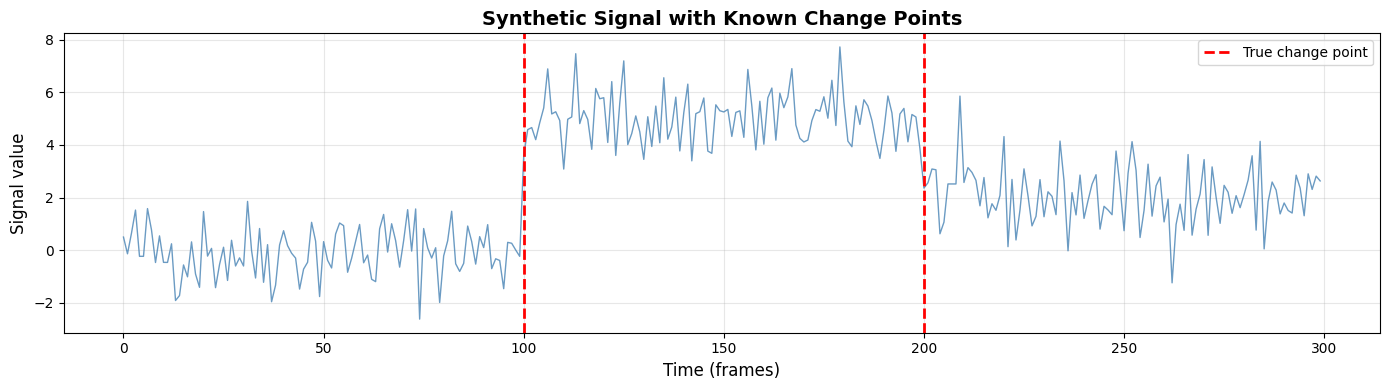

True change points: [100, 200]


In [ ]:
# Create synthetic signal with known change points
n_samples = 300
true_changepoints = [100, 200]

segment1 = np.random.randn(100) + 0   # Low mean
segment2 = np.random.randn(100) + 3   # High mean
segment3 = np.random.randn(100) + 2   # Medium mean

signal_synthetic = np.concatenate([segment1, segment2, segment3])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(signal_synthetic, linewidth=1, color='steelblue', alpha=0.8)
for cp in true_changepoints:
    ax.axvline(cp, color='red', linestyle='--', linewidth=2,
               label='True change point' if cp == true_changepoints[0] else '')
ax.set_xlabel('Time (frames)', fontsize=12)
ax.set_ylabel('Signal value', fontsize=12)
ax.set_title('Synthetic Signal with Known Change Points', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"True change points: {true_changepoints}")

### Apply Binary Segmentation

In [4]:
# Binary Segmentation (Binseg) -- tells it to find exactly 2 breakpoints
algo = rpt.Binseg(model="l2", min_size=10).fit(signal_synthetic)
detected_bkps = algo.predict(n_bkps=2)

print(f"Detected change points: {detected_bkps[:-1]}")
print(f"True change points:     {true_changepoints}")
print(f"\nError (frames): {[abs(d-t) for d, t in zip(detected_bkps[:-1], true_changepoints)]}") 

Detected change points: [100, 200]
True change points:     [100, 200]

Error (frames): [0, 0]


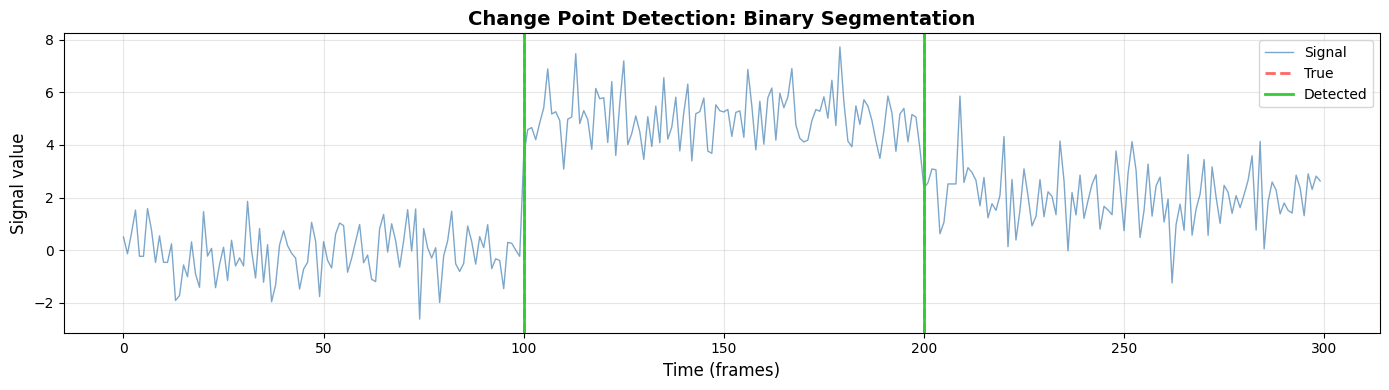

In [5]:
# Visualize Binary Segmentation result
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(signal_synthetic, linewidth=1, alpha=0.7, color='steelblue', label='Signal')
for cp in true_changepoints:
    ax.axvline(cp, color='red', linestyle='--', linewidth=2, alpha=0.6,
               label='True' if cp == true_changepoints[0] else '')
for cp in detected_bkps[:-1]:
    ax.axvline(cp, color='limegreen', linestyle='-', linewidth=2,
               label='Detected' if cp == detected_bkps[0] else '')
ax.set_xlabel('Time (frames)', fontsize=12)
ax.set_ylabel('Signal value', fontsize=12)
ax.set_title('Change Point Detection: Binary Segmentation', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Apply PELT Algorithm

PELT uses a **penalty** instead of a fixed number of breakpoints:
- **Lower penalty** → more breakpoints (fine-grained segmentation)
- **Higher penalty** → fewer breakpoints (coarse segmentation)


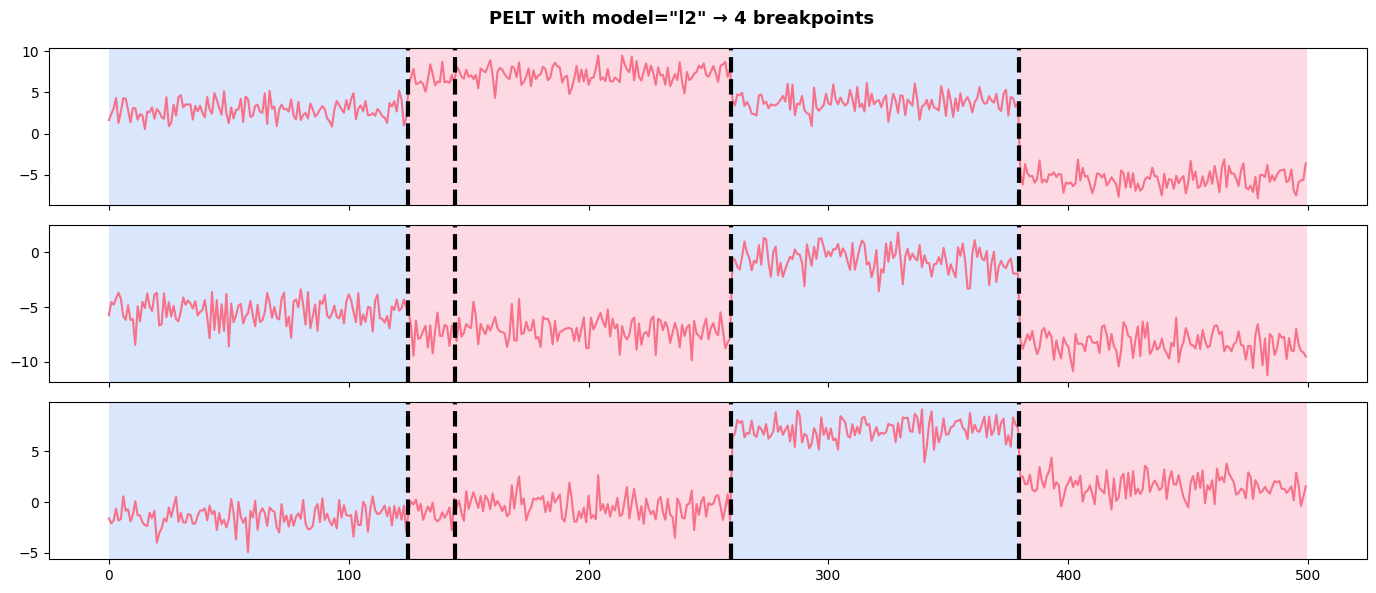

Model=l2: 4 detected, 3 true


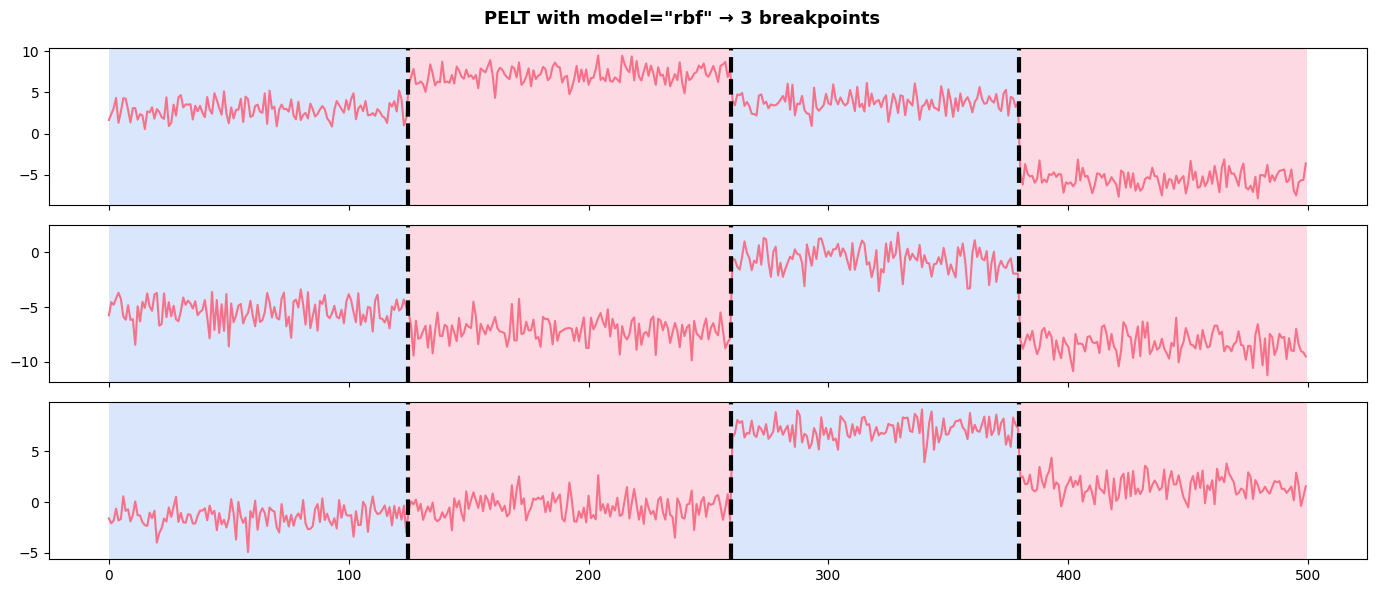

Model=rbf: 3 detected, 3 true


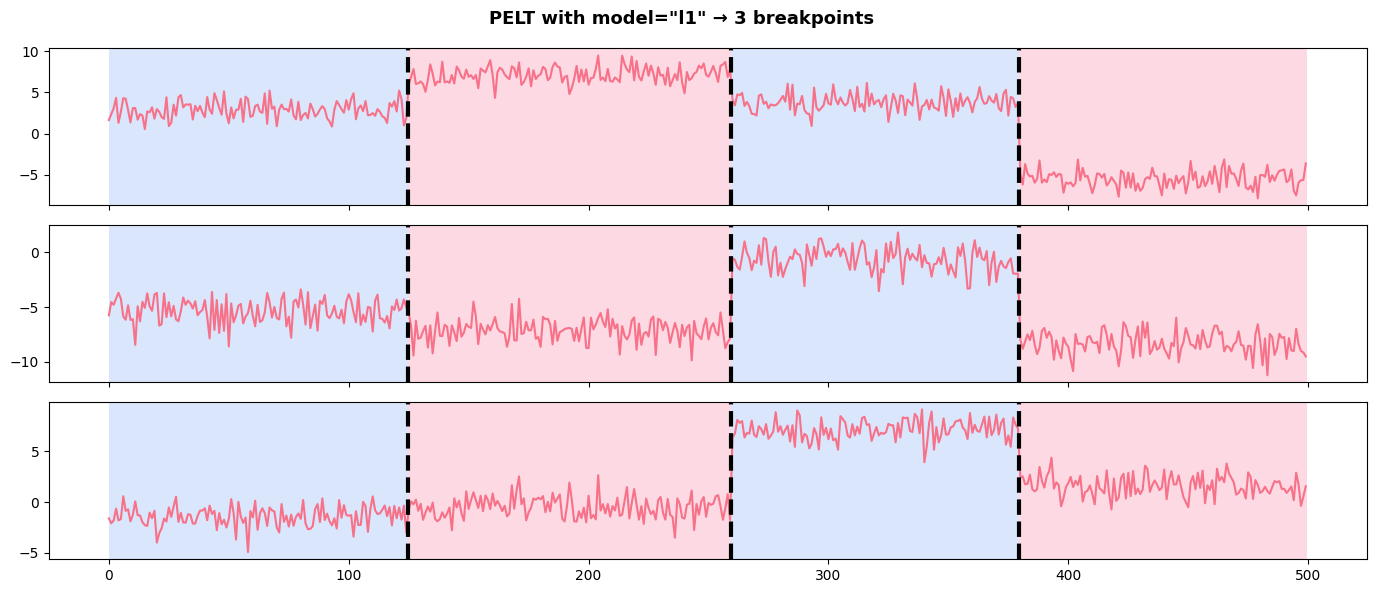

Model=l1: 3 detected, 3 true


In [7]:
# PELT on synthetic multidimensional data
n, dim = 500, 3
n_bkps_true, sigma = 3, 1
this_signal, true_bkps = rpt.pw_constant(n, dim, n_bkps_true, noise_std=sigma)

for model_name in ["l2", "rbf", "l1"]:
    algo = rpt.Pelt(model=model_name, min_size=3, jump=5).fit(this_signal)
    my_bkps = algo.predict(pen=10)
    fig, ax_arr = rpt.display(this_signal, true_bkps, my_bkps, figsize=(14, 6))
    plt.suptitle(f'PELT with model="{model_name}" → {len(my_bkps)-1} breakpoints', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Model={model_name}: {len(my_bkps)-1} detected, {n_bkps_true} true")

---

# Part 2: Applying Change Point Detection to Real Data

## 2.1 Select a Single Trial


In [9]:
# Select a single trial for detailed exploration
trial_ids = df['trial_id'].unique()
print(f"Available trials: {len(trial_ids)}")

# Choose a trial (you can change this number)
selected_trial = trial_ids[10]
trial_df = df[df['trial_id'] == selected_trial].copy()

print(f"\nAnalyzing trial: {selected_trial}")
print(f"Number of frames: {len(trial_df)}")
print(f"Duration: {trial_df['time'].max():.2f} seconds")
print(f"Success: {trial_df['success'].iloc[0]}")

Available trials: 139

Analyzing trial: 10
Number of frames: 1418
Duration: 28.34 seconds
Success: 1


## 2.2 Feature Engineering

### Speed Calculation

$$\text{speed}(t) = \frac{\sqrt{(x_{t+1}-x_t)^2 + (z_{t+1}-z_t)^2}}{\Delta t}$$


In [10]:
def calculate_2d_speed(x, z, dt=None):
    """
    Calculate 2D speed from position data (x and z plane).
    
    Parameters:
    -----------
    x, z : array-like
        Position coordinates
    dt : float, optional
        Time step in seconds. If None, returns distance per frame.
    
    Returns:
    --------
    speed : array (length = n-1)
        Speed at each time step
    """
    dx = np.diff(x)
    dz = np.diff(z)
    distance = np.sqrt(dx**2 + dz**2)
    return distance / dt if dt is not None else distance

# Estimate dt from time column
dt = np.median(np.diff(trial_df['time'].values))
print(f"Time step (dt): {dt:.4f} seconds  |  Frame rate: {1/dt:.1f} Hz")

speed = calculate_2d_speed(trial_df['x'].values, trial_df['z'].values, dt=dt)
speed_padded = np.concatenate([[speed[0]], speed])
trial_df['speed'] = speed_padded

print(f"Speed range: {speed.min():.2f} - {speed.max():.2f} cm/s")
print(f"Mean speed: {speed.mean():.2f} cm/s")

Time step (dt): 0.0200 seconds  |  Frame rate: 50.0 Hz
Speed range: 0.00 - 2.96 cm/s
Mean speed: 0.24 cm/s


### Angular Velocity — and Why It Gets Noisy

Angular velocity is computed from consecutive yaw angle differences:

$$\omega(t) = \frac{\text{yaw}_{t+1} - \text{yaw}_t}{\Delta t}$$

**Problem**: When the yaw angle wraps around ±180° (e.g., jumps from 179° to −179°), a simple difference produces a **spurious spike** of ~360°/dt, which is not a real rotation. Even after `np.unwrap()`, tracking noise or momentary occlusion can still produce implausibly large values.

**Solution pipeline**:
1. Unwrap angles to remove wrap-around discontinuities
2. Compute raw angular velocity
3. **Remove outliers**: values above a physiological threshold (e.g. > 30 rad/s ≈ ~1720°/s, well above what a rat can turn) are replaced with `NaN`
4. **Interpolate** the NaN gaps so that downstream algorithms (which require no NaN) work cleanly


In [11]:
def calculate_angular_velocity(yaw, dt, outlier_threshold=30.0):
    """
    Calculate angular velocity from yaw angle with noise control.
    
    Parameters:
    -----------
    yaw : array-like
        Yaw angles in degrees
    dt : float
        Time step in seconds
    outlier_threshold : float
        Maximum plausible angular velocity in rad/s.
        Values above this are set to NaN (physiologically implausible).
        Default 30 rad/s ≈ 1720 deg/s (well above rat turning speed).
    
    Returns:
    --------
    angular_vel : array (length = n)
        Angular velocity in rad/s.  NaN values are linearly interpolated.
    nan_mask : boolean array
        True where a value was originally an outlier/NaN
    """
    # Convert degrees to radians
    rad_yaw = np.deg2rad(yaw)
    
    # Unwrap to remove ±π wrap-around artefacts
    unwrapped = np.unwrap(rad_yaw)
    
    # Compute raw angular velocity (length = n-1)
    dyaw = np.diff(unwrapped)
    angular_vel_raw = dyaw / dt
    
    # ── Outlier removal ──────────────────────────────────────────────────
    nan_mask_raw = np.abs(angular_vel_raw) > outlier_threshold
    n_outliers = nan_mask_raw.sum()
    pct = 100 * n_outliers / len(angular_vel_raw)
    print(f"  Outliers removed: {n_outliers} frames ({pct:.1f}%) above {outlier_threshold} rad/s")
    
    angular_vel_clean = angular_vel_raw.copy().astype(float)
    angular_vel_clean[nan_mask_raw] = np.nan
    
    # ── Interpolation ────────────────────────────────────────────────────
    # Use linear interpolation to fill NaN gaps; extrapolate edges with nearest value
    t = np.arange(len(angular_vel_clean))
    valid = ~np.isnan(angular_vel_clean)
    if valid.sum() < 2:
        angular_vel_interp = np.zeros_like(angular_vel_clean)
    else:
        f = interp1d(t[valid], angular_vel_clean[valid],
                     kind='linear', bounds_error=False,
                     fill_value=(angular_vel_clean[valid][0], 
                                 angular_vel_clean[valid][-1]))
        angular_vel_interp = f(t)
    
    # Pad to original length (repeat first value)
    angular_vel_padded = np.concatenate([[angular_vel_interp[0]], angular_vel_interp])
    nan_mask_padded    = np.concatenate([[False], nan_mask_raw])
    
    return angular_vel_padded, nan_mask_padded


# ── Apply to trial ────────────────────────────────────────────────────────
print("Computing angular velocity...")
ang_vel, nan_mask = calculate_angular_velocity(trial_df['yaw'].values, dt, outlier_threshold=30.0)
trial_df['angular_velocity'] = ang_vel
trial_df['ang_vel_outlier']  = nan_mask

print(f"\nAngular velocity range (after cleaning): "
      f"{ang_vel.min():.2f} - {ang_vel.max():.2f} rad/s")

Computing angular velocity...
  Outliers removed: 5 frames (0.4%) above 30.0 rad/s

Angular velocity range (after cleaning): -20.69 - 13.63 rad/s


## 2.3 Visualize Raw vs Cleaned Angular Velocity

Let's see the effect of the outlier removal step.

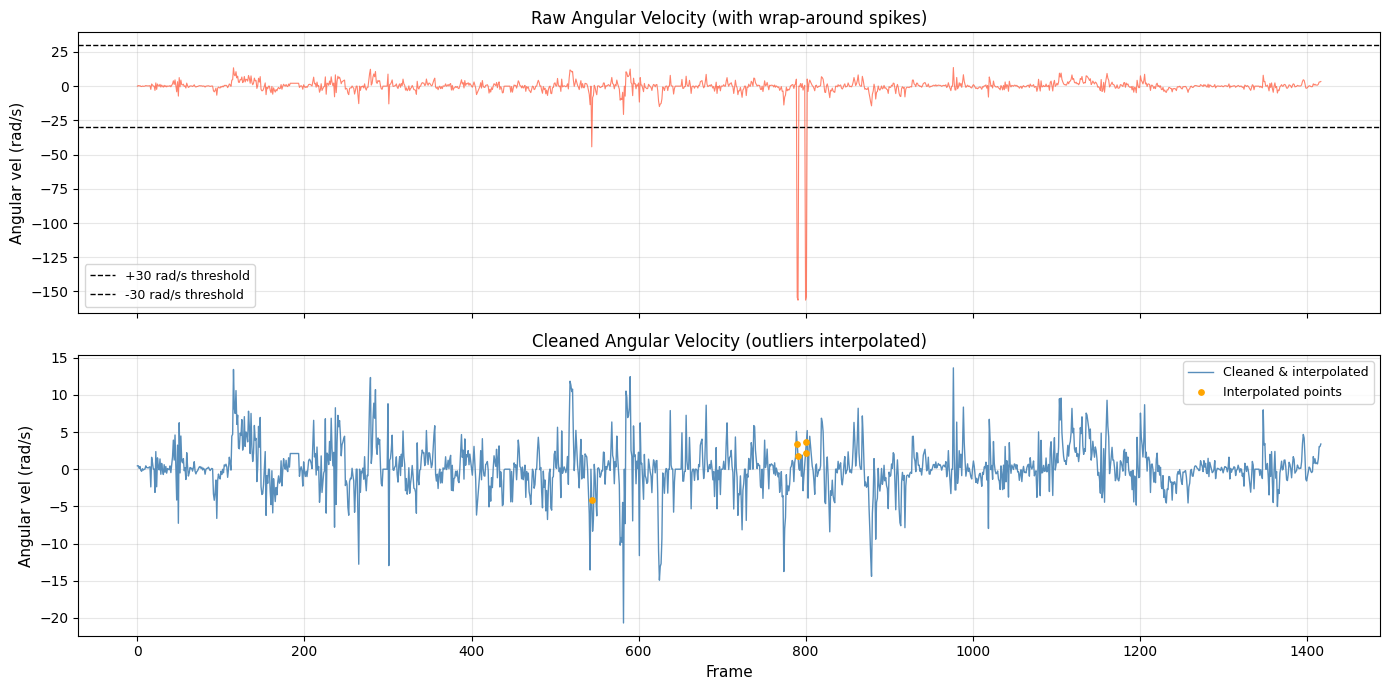

💡 Orange dots show frames where the original value was an outlier and was interpolated.


In [12]:
# Recompute raw (no threshold) for comparison
rad_yaw = np.deg2rad(trial_df['yaw'].values)
unwrapped = np.unwrap(rad_yaw)
ang_vel_raw = np.concatenate([[0], np.diff(unwrapped) / dt])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(trial_df['frame'], ang_vel_raw, linewidth=0.8, color='tomato', alpha=0.8)
axes[0].set_ylabel('Angular vel (rad/s)', fontsize=11)
axes[0].set_title('Raw Angular Velocity (with wrap-around spikes)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(30, color='black', linestyle='--', linewidth=1, label='+30 rad/s threshold')
axes[0].axhline(-30, color='black', linestyle='--', linewidth=1, label='-30 rad/s threshold')
axes[0].legend(fontsize=9)

axes[1].plot(trial_df['frame'], trial_df['angular_velocity'], linewidth=1, 
             color='steelblue', alpha=0.9, label='Cleaned & interpolated')
# Highlight where outliers were
axes[1].scatter(trial_df['frame'][trial_df['ang_vel_outlier']],
                trial_df['angular_velocity'][trial_df['ang_vel_outlier']],
                color='orange', s=15, zorder=5, label='Interpolated points')
axes[1].set_ylabel('Angular vel (rad/s)', fontsize=11)
axes[1].set_xlabel('Frame', fontsize=11)
axes[1].set_title('Cleaned Angular Velocity (outliers interpolated)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("💡 Orange dots show frames where the original value was an outlier and was interpolated.")

## 2.4 Visualize All Features

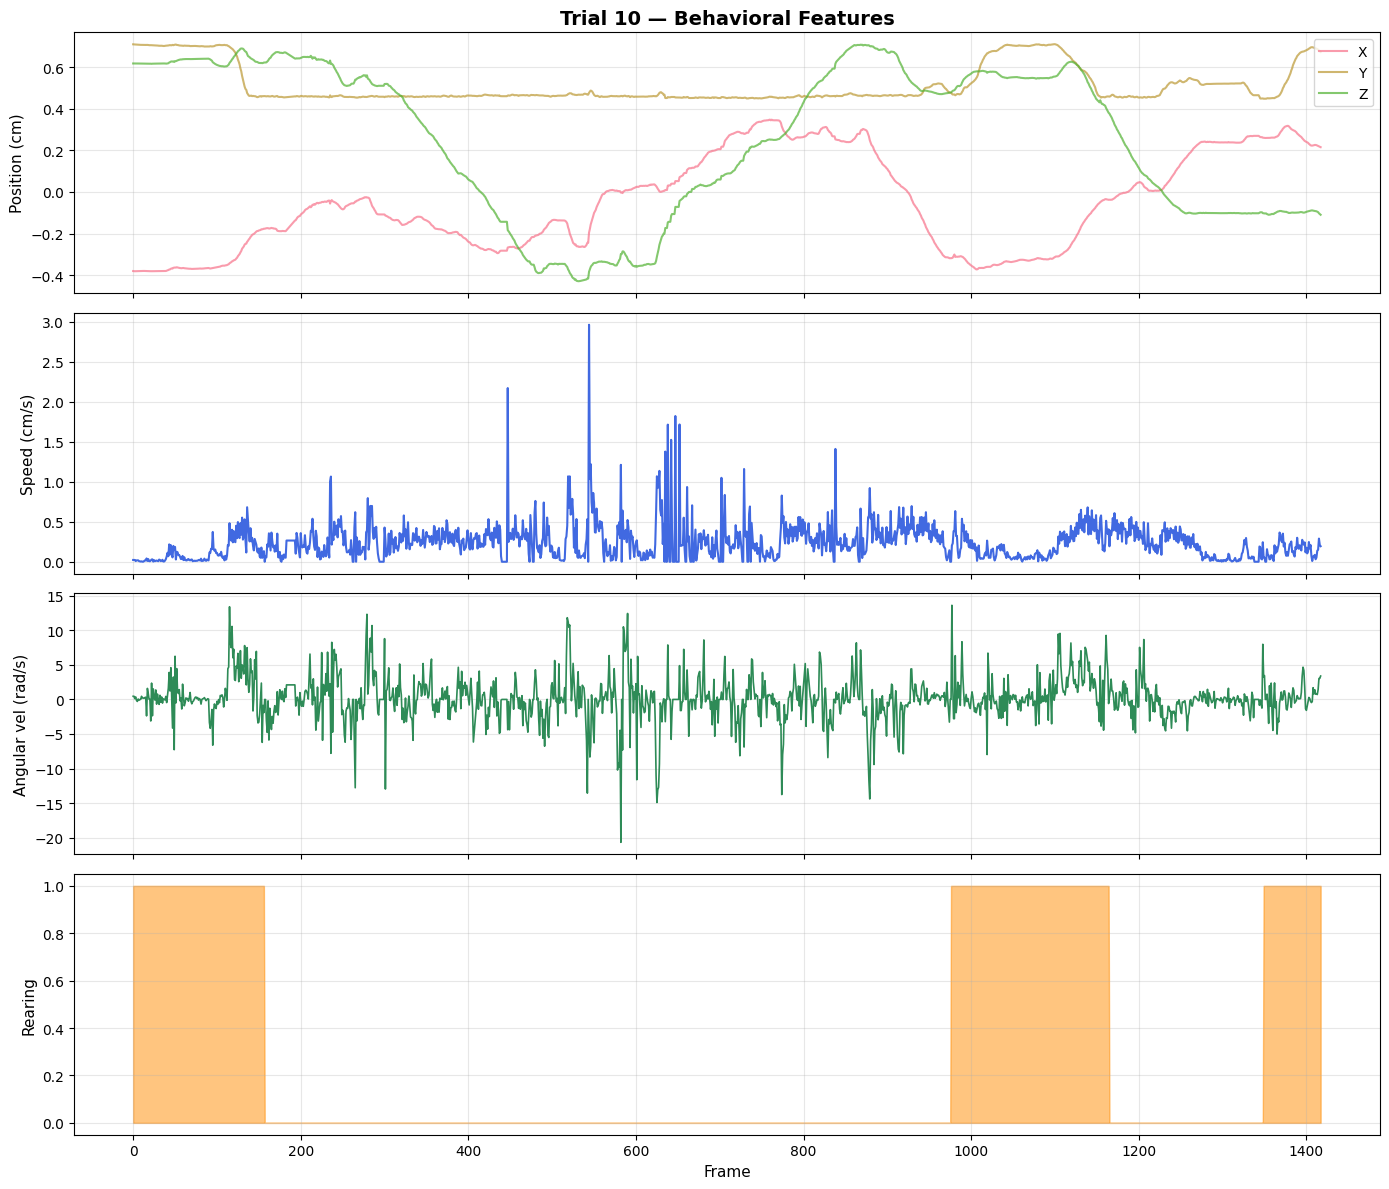

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(trial_df['frame'], trial_df['x'], label='X', alpha=0.7)
axes[0].plot(trial_df['frame'], trial_df['y'], label='Y', alpha=0.7)
axes[0].plot(trial_df['frame'], trial_df['z'], label='Z', alpha=0.7)
axes[0].set_ylabel('Position (cm)', fontsize=11)
axes[0].set_title(f'Trial {selected_trial} — Behavioral Features', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(trial_df['frame'], trial_df['speed'], color='royalblue', linewidth=1.5)
axes[1].set_ylabel('Speed (cm/s)', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(trial_df['frame'], trial_df['angular_velocity'], color='seagreen', linewidth=1.2)
axes[2].set_ylabel('Angular vel (rad/s)', fontsize=11)
axes[2].grid(True, alpha=0.3)

axes[3].fill_between(trial_df['frame'], 0, trial_df['rearing'], color='darkorange', alpha=0.5)
axes[3].set_ylabel('Rearing', fontsize=11)
axes[3].set_xlabel('Frame', fontsize=11)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 2.5 Single-Feature Change Point Detection

Let's start with speed only before moving to multiple features.

### Smoothing

We apply a Savitzky-Golay filter to the speed signal before change-point detection. This removes high-frequency jitter while preserving the shape of transitions:

$$x_{\text{smooth}}[i] \approx \text{local polynomial fit of order } p \text{ over window } w$$


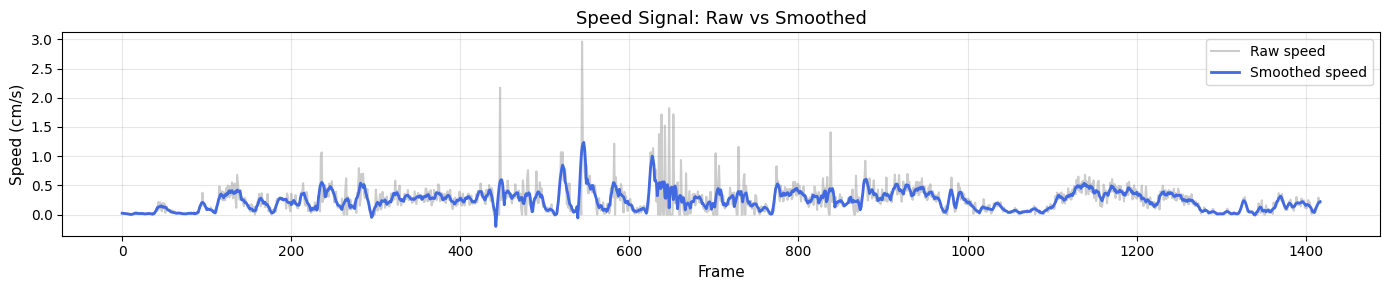

In [ ]:
speed_signal = trial_df['speed'].values
smooth_speed = signal.savgol_filter(speed_signal, window_length=11, polyorder=3)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(trial_df['frame'], speed_signal, alpha=0.4, label='Raw speed', color='gray')
ax.plot(trial_df['frame'], smooth_speed, linewidth=2, label='Smoothed speed', color='royalblue')
ax.set_xlabel('Frame', fontsize=11)
ax.set_ylabel('Speed (cm/s)', fontsize=11)
ax.set_title('Speed Signal: Raw vs Smoothed', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [27]:
trial_df['speed_smooth'] = smooth_speed

In [ ]:
#smooth angular velocity
smooth_ang_vel = signal.savgol_filter(trial_df['angular_velocity'].values, window_length=11, polyorder=3)
trial_df['angular_velocity_smooth'] = smooth_ang_vel



---

## 🎯 Exercise 1: Choose the Right Penalty

### Background

The penalty $\beta$ in the PELT objective controls the trade-off between fit quality and model complexity:

$$\text{score} = \underbrace{\sum \text{cost(segments)}}_{\text{fit}} + \underbrace{\beta \cdot k}_{\text{complexity}}$$

- **$\beta$ too small** → every little wiggle becomes a segment (over-segmentation)
- **$\beta$ too large** → real transitions are missed (under-segmentation)
- **Right $\beta$** → change points align with genuine behavioral transitions

**Your task**: Run PELT with several penalties and decide which gives the most *behaviorally meaningful* segmentation.


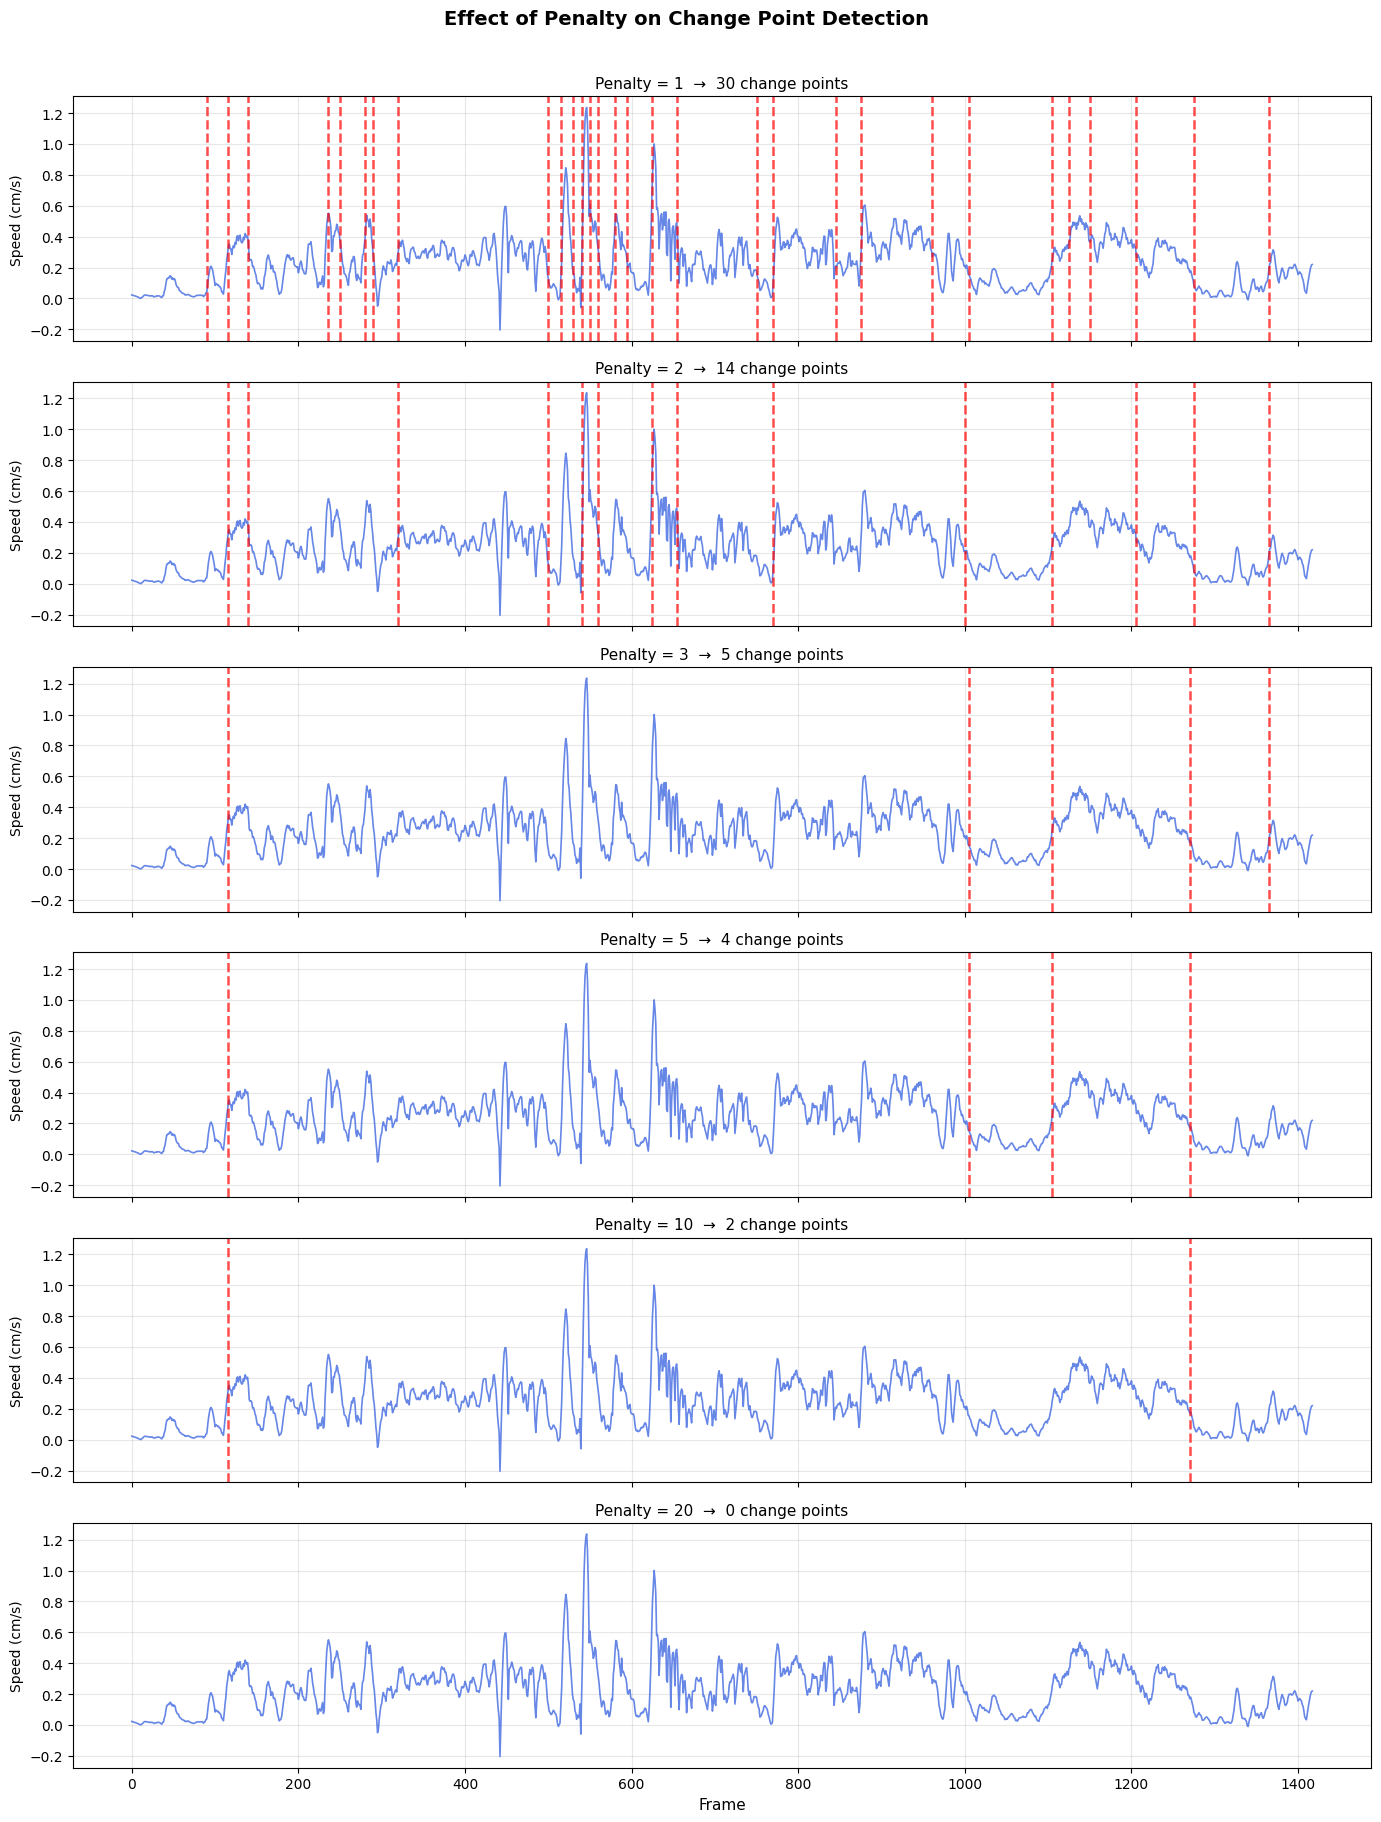


💡 Notice: higher penalty = fewer change points


In [21]:
# =============================================================================
# EXERCISE 1: Choosing the Right Penalty
# =============================================================================
# TODO: Fill in the `penalties` list with values that span a wide range.
#       Try at least 6 values from very small (e.g. 0.5) to very large (e.g. 50).
#
# HINT: Start with: [0.5, 1, 3, 5, 10, 20, 50]
# HINT: After plotting, pick the penalty where the change points look "right" to
#       you — not too many, not too few.

# YOUR CODE HERE
penalties = [1, 2,3, 5, 10, 20]  # <-- replace with your chosen range

# ── Plotting (no need to change below) ──────────────────────────────────────
algo_speed = rpt.Pelt(model="l1", min_size=10).fit(smooth_speed)

fig, axes = plt.subplots(len(penalties), 1, figsize=(14, 3*len(penalties)), sharex=True)

for idx, pen in enumerate(penalties):
    bkps = algo_speed.predict(pen=pen)
    ax = axes[idx]
    ax.plot(trial_df['frame'], smooth_speed, linewidth=1.2, alpha=0.8, color='royalblue')
    for bkp in bkps[:-1]:
        ax.axvline(trial_df['frame'].iloc[bkp], color='red', linestyle='--', linewidth=1.8, alpha=0.7)
    ax.set_ylabel('Speed (cm/s)', fontsize=10)
    ax.set_title(f'Penalty = {pen}  →  {len(bkps)-1} change points', fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame', fontsize=11)
plt.suptitle('Effect of Penalty on Change Point Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("\n💡 Notice: higher penalty = fewer change points")

In [ ]:
# =============================================================================
# EXERCISE 1 (continued): Record your best penalty
# =============================================================================
# TODO: Based on the plots above, set best_penalty to the value you prefer.
# HINT: Look for the penalty where the red dashed lines align with visible
#       transitions in the speed signal.

# YOUR CODE HERE
best_penalty_speed = 5   # <-- replace with your choice

bkps_speed = rpt.Pelt(model="l2", min_size=10).fit(smooth_speed).predict(pen=best_penalty_speed)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(trial_df['frame'], smooth_speed, linewidth=1.5, color='royalblue', label='Speed')
for i, bkp in enumerate(bkps_speed[:-1]):
    ax.axvline(trial_df['frame'].iloc[bkp], color='red', linestyle='--', linewidth=2, alpha=0.7,
               label='Change point' if i == 0 else '')
ax.set_xlabel('Frame', fontsize=12)
ax.set_ylabel('Speed (cm/s)', fontsize=12)
ax.set_title(f'Best Penalty = {best_penalty_speed}  →  {len(bkps_speed)-1} segments', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Check ───────────────────────────────────────────────────────────────────
assert isinstance(best_penalty_speed, (int, float)) and best_penalty_speed > 0, "Penalty must be positive"
assert 1 <= len(bkps_speed)-1 <= 30, "Number of segments seems unreasonable (check your penalty)"
print(f"✓ Using penalty={best_penalty_speed} → {len(bkps_speed)-1} change points")

<details>
<summary>💡 Solution hints (click to expand)</summary>

```python
# Typical good range for this dataset:
penalties = [0.5, 1, 2, 5, 10, 20, 50]

# A penalty around 3-8 often gives 5-15 segments for a ~200-frame trial,
# which corresponds to distinct locomotion bouts.
# Very low (<1): dozens of tiny segments — over-segmentation
# Very high (>20): 1-3 segments — misses real transitions
best_penalty_speed = 5  # adjust based on your visual inspection
```
</details>


---

## 🎯 Exercise 2: Compare Detection Models

### Background

Different cost functions detect different *kinds* of change:

- **`l2`** minimises squared deviations → detects **shifts in the mean**; fast but sensitive to outliers
- **`l1`** minimises absolute deviations → detects **shifts in the median**; more robust to outliers
- **`rbf`** uses a kernel measure of distributional distance → detects **any distributional change** (mean, variance, shape)

For noisy animal tracking data, `l1` or `rbf` often produce cleaner results than `l2`.

**Your task**: Fit PELT with all three models using the same penalty and compare the detected breakpoints.


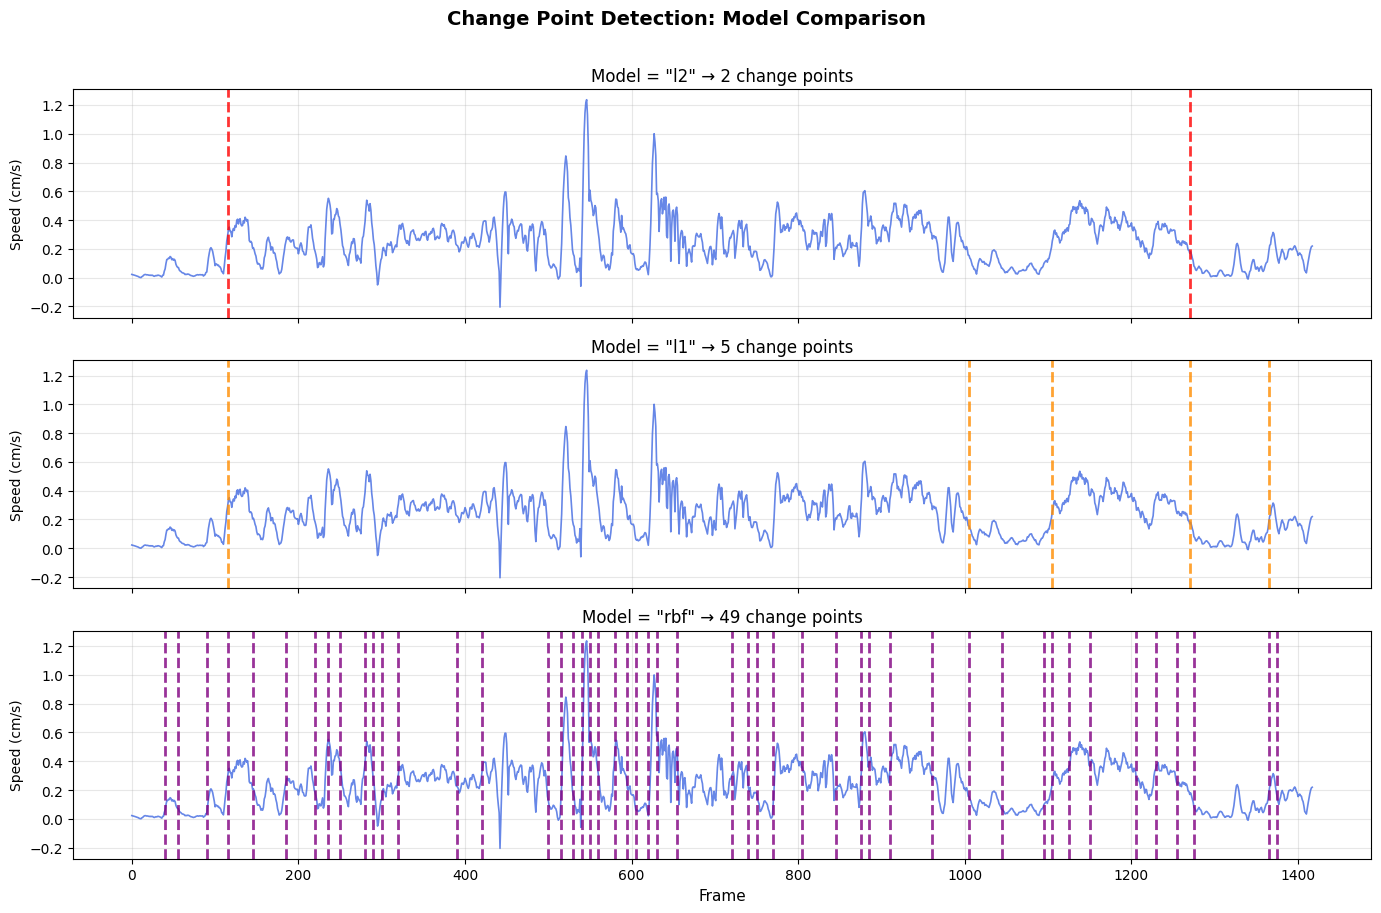

In [22]:
# =============================================================================
# EXERCISE 2: Compare l2, l1, and rbf models
# =============================================================================
# TODO: Complete the loop to run PELT with each model.
# HINT: Use the same penalty as your best_penalty_speed from Exercise 1.
# HINT: rpt.Pelt(model=<model_name>, min_size=10).fit(smooth_speed).predict(pen=<penalty>)

models_to_compare = ["l2", "l1", "rbf"]

# YOUR CODE HERE — fill in the dict values:
model_bkps = {}
for m in models_to_compare:
    # model_bkps[m] = ???
    pass  # replace this with your code

# =============================================================================
# SOLUTION (uncomment to reveal):
# =============================================================================
for m in models_to_compare:
    model_bkps[m] = rpt.Pelt(model=m, min_size=10).fit(smooth_speed).predict(pen=3)

# ── Plotting ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(models_to_compare), 1, figsize=(14, 9), sharex=True)
colors_model = {'l2': 'red', 'l1': 'darkorange', 'rbf': 'purple'}

for idx, m in enumerate(models_to_compare):
    ax = axes[idx]
    ax.plot(trial_df['frame'], smooth_speed, linewidth=1.2, alpha=0.8, color='royalblue')
    bkps_m = model_bkps.get(m, [])
    for bkp in bkps_m[:-1] if bkps_m else []:
        ax.axvline(trial_df['frame'].iloc[bkp], color=colors_model[m],
                   linestyle='--', linewidth=2, alpha=0.8)
    n_bkp = len(bkps_m)-1 if bkps_m else '?'
    ax.set_title(f'Model = "{m}" → {n_bkp} change points', fontsize=12)
    ax.set_ylabel('Speed (cm/s)', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame', fontsize=11)
plt.suptitle('Change Point Detection: Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# EXERCISE 2 (continued): Choose your best model
# =============================================================================
# TODO: Set best_model to whichever model you prefer based on the plots above.

# YOUR CODE HERE
best_model = "l2"  # <-- replace: "l2", "l1", or "rbf"

print(f"✓ You chose model='{best_model}'")
print(f"  Number of change points: {len(model_bkps.get(best_model, []))-1}")

# ── Reflection questions ─────────────────────────────────────────────────────
print("""
✍️  Reflection Questions:
1. Which model gave the cleanest segmentation for this data?
2. Do l1 and l2 give similar results, or very different? Why might that be?
3. When would you prefer rbf over l2?
""")

<details>
<summary>💡 Guidance (click to expand)</summary>

```python
# For animal tracking data with occasional tracking artefacts:
# - 'l1' is usually a better default than 'l2' (robust to outliers)
# - 'rbf' can catch variance changes (e.g., jittery vs smooth movement)
# - 'l2' is fine when data is clean

best_model = "l1"  # good robust default
```
</details>


---

## 2.6 Multi-Feature Change Point Detection

Speed alone may miss transitions where heading changes but speed doesn't. Let's combine:
- Speed
- Angular velocity
- Vertical position (z)

### Feature Normalization

**Critical**: features have different scales. We must z-score each:

$$z_i = \frac{x_i - \mu_i}{\sigma_i}$$

This ensures each feature contributes equally to the cost function.


In [59]:
from sklearn.preprocessing import StandardScaler

# Select features
# features = ['speed_smooth', 'angular_velocity_smooth', 'y']
features = ['speed', 'angular_velocity']  # <-- if you want to use raw instead of smoothed
X = trial_df[features].values

# Handle any remaining NaN with interpolation
for i, feat in enumerate(features):
    if np.isnan(X[:, i]).any():
        nans = np.isnan(X[:, i])
        X[nans, i] = np.interp(np.where(nans)[0],
                                np.where(~nans)[0],
                                X[~nans, i])

# Normalize
scaler = StandardScaler()
## smooth speed and angular velocity to reduce noise before multivariate detection

X_normalized = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_normalized.shape}")
print(f"Feature means (should be ≈0): {X_normalized.mean(axis=0).round(3)}")
print(f"Feature stds  (should be ≈1): {X_normalized.std(axis=0).round(3)}")
print(f"Any NaN remaining: {np.isnan(X_normalized).any()}")

Feature matrix shape: (1418, 2)
Feature means (should be ≈0): [0. 0.]
Feature stds  (should be ≈1): [1. 1.]
Any NaN remaining: False


---

## 🎯 Exercise 3: Multi-Feature Segmentation

Now apply what you learned in Exercises 1 and 2 to the **multi-dimensional** feature matrix.

**Your task**:
1. Think about how many features you want to include, I only add the speed, angular velocity, z, but you can add more
2. whether to smooth the speed, angular velocity or not
3. Choose a model and a penalty
4. Try a few penalties to find a good one
5. Visualize the segmentation across all features


In [60]:
# =============================================================================
# EXERCISE 3: Multi-feature change point detection
# =============================================================================
# TODO: Fill in `pen_multi` and run PELT on X_normalized.
#
# HINT: Multi-dimensional signals often need a slightly higher penalty than 1D,
#       because summed costs across features are larger.
#       Try 5-30 for this dataset.
# HINT: rpt.Pelt(model=best_model, min_size=15).fit(X_normalized).predict(pen=pen_multi)

# YOUR CODE HERE
pen_multi = 10  # <-- try different values!
# algo_multi = rpt.Pelt(model=???, min_size=15).fit(???)
# bkps_multi = algo_multi.predict(pen=pen_multi)

# =============================================================================
# SOLUTION (uncomment to reveal):
# =============================================================================
algo_multi = rpt.Pelt(model="l1", min_size=15).fit(X_normalized)
bkps_multi = algo_multi.predict(pen=pen_multi)

print(f"Detected {len(bkps_multi)-1} change points with penalty={pen_multi}")
print(f"Frame indices: {bkps_multi[:-1]}")

Detected 10 change points with penalty=10
Frame indices: [115, 145, 545, 560, 770, 1005, 1105, 1150, 1270, 1365]


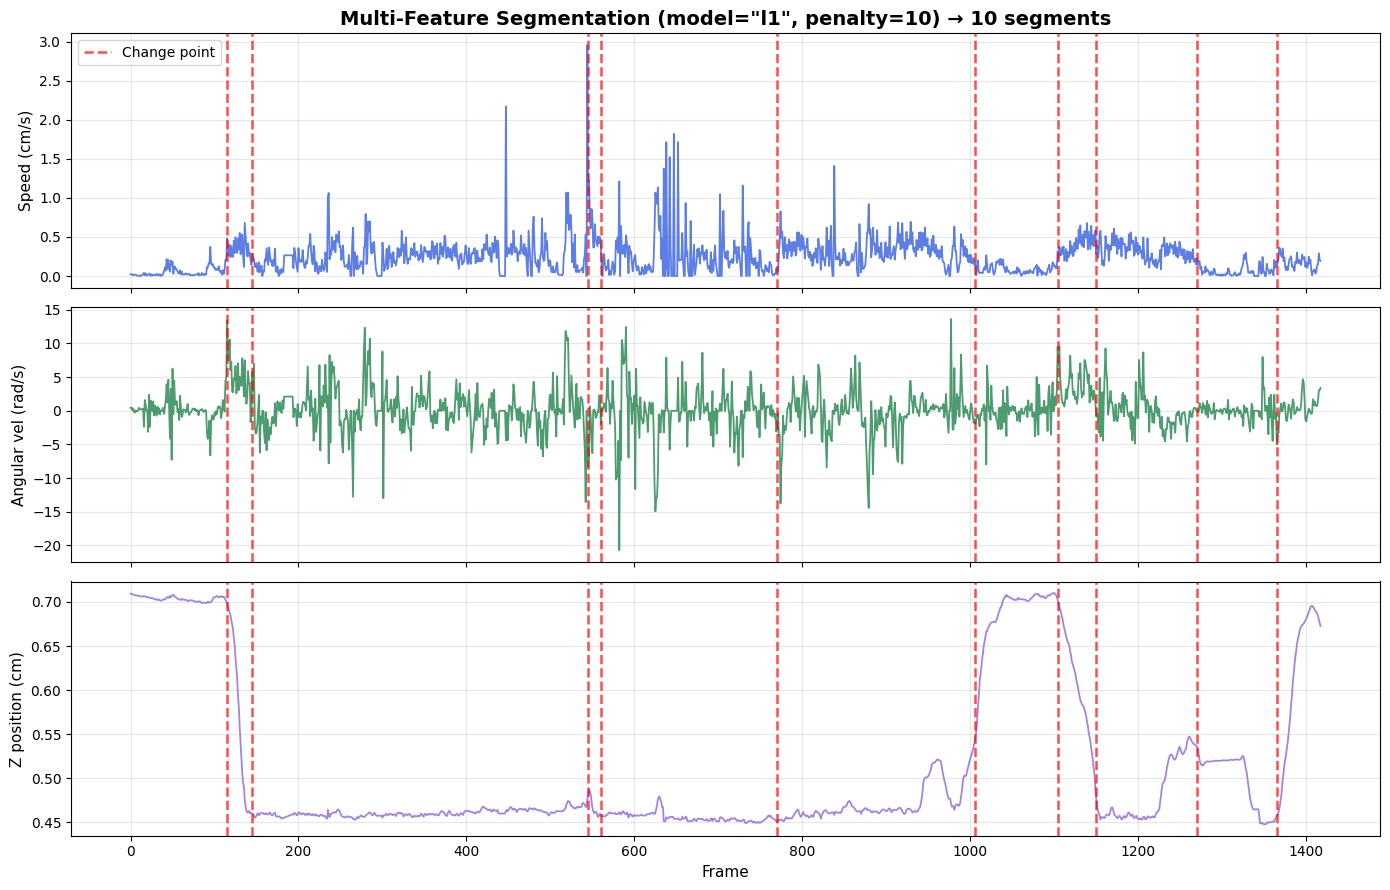

✓ 10 segments detected


In [61]:
# Visualize multi-feature segmentation
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

feature_labels = ['Speed (cm/s)', 'Angular vel (rad/s)', 'Z position (cm)']
feature_keys   = ['speed', 'angular_velocity', 'y']
feature_colors = ['royalblue', 'seagreen', 'mediumpurple']

for idx, (ax, key, label, color) in enumerate(zip(axes, feature_keys, feature_labels, feature_colors)):
    ax.plot(trial_df['frame'], trial_df[key], linewidth=1.3, alpha=0.85, color=color)
    for bkp in bkps_multi[:-1]:
        ax.axvline(trial_df['frame'].iloc[bkp], color='red', linestyle='--',
                   linewidth=1.8, alpha=0.7,
                   label='Change point' if bkp == bkps_multi[0] and idx == 0 else '')
    ax.set_ylabel(label, fontsize=11)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=10)

axes[0].set_title(f'Multi-Feature Segmentation (model="l1", penalty={pen_multi}) '
                  f'→ {len(bkps_multi)-1} segments', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Frame', fontsize=11)
plt.tight_layout()
plt.show()

# Check work
assert len(bkps_multi) > 1, "No change points detected — try a smaller penalty"
assert len(bkps_multi) < len(trial_df) / 5, "Too many change points — try a larger penalty"
print(f"✓ {len(bkps_multi)-1} segments detected")

---

## 2.7 Segment Characterization

Each segment is now a "behavioral bout". Let's compute summary statistics per segment to understand what the animal was doing.


In [62]:
# Assign segment IDs to each frame
segment_ids = np.zeros(len(trial_df), dtype=int)
for seg_idx, (start, end) in enumerate(zip([0] + bkps_multi[:-1], bkps_multi)):
    segment_ids[start:end] = seg_idx

trial_df['segment'] = segment_ids

# Compute per-segment statistics
segment_stats = trial_df.groupby('segment').agg(
    speed_mean=('speed', 'mean'),
    speed_std=('speed', 'std'),
    angvel_mean=('angular_velocity', 'mean'),
    angvel_abs_mean=('angular_velocity', lambda v: np.abs(v).mean()),
    z_mean=('z', 'mean'),
    rearing_frac=('rearing', 'mean'),
    n_frames=('frame', 'count')
).round(3)

print("Segment Statistics:")
print(segment_stats)

print("\n💡 Behavioral Interpretation Guide:")
print("  High speed + low |angular vel|  → Directed, straight movement")
print("  Low speed + high |angular vel|  → Turning / searching")
print("  Increasing z + rearing > 0     → Climbing / rearing")
print("  Low speed + low |angular vel|  → Pausing / stationary")

Segment Statistics:
         speed_mean  speed_std  angvel_mean  angvel_abs_mean  z_mean  \
segment                                                                
0             0.053      0.062        0.070            1.030   0.624   
1             0.348      0.130        4.871            4.982   0.659   
2             0.264      0.241        0.171            2.252   0.217   
3             0.621      0.258       -1.553            2.282  -0.344   
4             0.255      0.322       -0.253            2.434  -0.063   
5             0.321      0.175       -0.366            2.135   0.546   
6             0.086      0.061        0.090            1.428   0.558   
7             0.395      0.128        3.618            3.618   0.571   
8             0.320      0.118       -0.141            1.882   0.112   
9             0.065      0.070       -0.014            0.822  -0.102   
10            0.172      0.083        0.380            1.237  -0.096   

         rearing_frac  n_frames  
segment  

### Visualize Segments in 3D Space

In [63]:
# 3D trajectory colored by segment (interactive plotly)
n_segments = trial_df['segment'].nunique()
palette = px.colors.qualitative.Set1

fig = go.Figure()

for seg_id in range(n_segments):
    seg_data = trial_df[trial_df['segment'] == seg_id]
    fig.add_trace(go.Scatter3d(
        x=seg_data['x'], y=seg_data['z'], z=seg_data['y'],
        mode='lines+markers',
        name=f'Segment {seg_id}',
        line=dict(color=palette[seg_id % len(palette)], width=3),
        marker=dict(size=2)
    ))

fig.update_layout(
    title=f'3D Trajectory — Trial {selected_trial} (colored by segment)',
    scene=dict(xaxis_title='X (cm)', yaxis_title='Z (cm)', zaxis_title='Y (cm)',
               aspectmode='data'),
    width=900, height=700
)
fig.show()

---

# Part 3: Batch Processing Multiple Trials

## 3.1 Segmentation Pipeline Function


In [64]:
def segment_trial(trial_data, features=None, model='l1',
                  penalty=10, min_size=15, ang_vel_threshold=30.0):
    """
    Full segmentation pipeline for one trial.

    Parameters:
    -----------
    trial_data : DataFrame
        Data for a single trial. Must contain: x, z, yaw, time, rearing columns.
    features : list or None
        Feature names to use. Default: ['speed', 'angular_velocity', 'z']
    model : str
        Ruptures cost model ('l1', 'l2', 'rbf')
    penalty : float
        PELT penalty parameter
    min_size : int
        Minimum segment length in frames
    ang_vel_threshold : float
        Max plausible angular velocity in rad/s (outlier removal)

    Returns:
    --------
    trial_data : DataFrame (copy with 'segment' column added)
    bkps : list of breakpoint frame indices
    segment_stats : DataFrame
    """
    if features is None:
        features = ['speed', 'angular_velocity', 'z']

    trial_data = trial_data.copy()
    dt = np.median(np.diff(trial_data['time'].values))

    # ── Compute features if not present ──────────────────────────────────
    if 'speed' not in trial_data.columns:
        spd = calculate_2d_speed(trial_data['x'].values, trial_data['z'].values, dt=dt)
        trial_data['speed'] = np.concatenate([[spd[0]], spd])

    if 'angular_velocity' not in trial_data.columns:
        ang_vel, _ = calculate_angular_velocity(
            trial_data['yaw'].values, dt, outlier_threshold=ang_vel_threshold)
        trial_data['angular_velocity'] = ang_vel

    # ── Extract & normalize features ─────────────────────────────────────
    X = trial_data[features].values.astype(float)
    for i in range(X.shape[1]):
        if np.isnan(X[:, i]).any():
            nans = np.isnan(X[:, i])
            X[nans, i] = np.interp(np.where(nans)[0],
                                    np.where(~nans)[0],
                                    X[~nans, i])
    X_norm = StandardScaler().fit_transform(X)

    # ── Change point detection ────────────────────────────────────────────
    algo = rpt.Pelt(model=model, min_size=min_size).fit(X_norm)
    bkps = algo.predict(pen=penalty)

    # ── Assign segment IDs ────────────────────────────────────────────────
    seg_ids = np.zeros(len(trial_data), dtype=int)
    for s, (start, end) in enumerate(zip([0] + bkps[:-1], bkps)):
        seg_ids[start:end] = s
    trial_data['segment'] = seg_ids

    stats = trial_data.groupby('segment').agg(
        speed_mean=('speed', 'mean'),
        angvel_abs_mean=('angular_velocity', lambda v: np.abs(v).mean()),
        z_mean=('z', 'mean'),
        rearing_frac=('rearing', 'mean'),
        n_frames=('frame', 'count')
    )

    return trial_data, bkps[:-1], stats


# Test function
trial_df_out, bkps_test, stats_test = segment_trial(trial_df)
print(f"✓ Segmentation function working!")
print(f"  Detected {len(bkps_test)} change points")

✓ Segmentation function working!
  Detected 22 change points


## 3.2 Process All Trials

In [75]:
# ── Process all trials ───────────────────────────────────────────────────
n_trials_to_process = min(130, len(trial_ids))  # limit for speed; increase if you like
print(f"Processing {n_trials_to_process} trials...")

all_segment_stats = []  # will hold per-segment feature vectors
trial_results      = []

for trial_id in trial_ids[:n_trials_to_process]:
    trial_data = df[df['trial_id'] == trial_id].copy()
    try:
        t_out, bkps, stats = segment_trial(trial_data, model='l1', penalty=pen_multi)
        stats['trial_id'] = trial_id
        stats['success']  = trial_data['success'].iloc[0]
        all_segment_stats.append(stats)
        trial_results.append({
            'trial_id': trial_id,
            'n_segments': len(bkps) + 1,
            'success': trial_data['success'].iloc[0],
            'n_frames': len(trial_data)
        })
    except Exception as e:
        print(f"  Skipping trial {trial_id}: {e}")

results_df      = pd.DataFrame(trial_results)
all_segs_df     = pd.concat(all_segment_stats, ignore_index=True)

print(f"\n✓ Processed {len(results_df)} trials")
print(f"  Total segments: {len(all_segs_df)}")

print("\n📊 Segments per trial by outcome:")
print(results_df.groupby('success')['n_segments'].agg(['mean', 'std', 'count']).round(2))

Processing 130 trials...
  Outliers removed: 7 frames (0.9%) above 30.0 rad/s
  Outliers removed: 2 frames (0.6%) above 30.0 rad/s
  Outliers removed: 0 frames (0.0%) above 30.0 rad/s
  Outliers removed: 0 frames (0.0%) above 30.0 rad/s
  Outliers removed: 3 frames (0.8%) above 30.0 rad/s
  Outliers removed: 0 frames (0.0%) above 30.0 rad/s
  Outliers removed: 12 frames (0.3%) above 30.0 rad/s
  Outliers removed: 0 frames (0.0%) above 30.0 rad/s
  Outliers removed: 5 frames (0.4%) above 30.0 rad/s
  Outliers removed: 4 frames (0.6%) above 30.0 rad/s
  Outliers removed: 5 frames (0.4%) above 30.0 rad/s
  Outliers removed: 0 frames (0.0%) above 30.0 rad/s
  Outliers removed: 0 frames (0.0%) above 30.0 rad/s
  Outliers removed: 7 frames (0.5%) above 30.0 rad/s
  Outliers removed: 5 frames (0.5%) above 30.0 rad/s
  Outliers removed: 1 frames (0.2%) above 30.0 rad/s
  Outliers removed: 7 frames (0.5%) above 30.0 rad/s
  Outliers removed: 6 frames (0.8%) above 30.0 rad/s
  Outliers removed: 

## The rest part will be the bonus part, feel free to explore

---

# Part 4: Clustering Behavioral Segments

## Why Cluster?

Change-point detection tells us *where* behavior changes, but not *what* the animal is doing in each segment. By clustering the segments by their feature statistics, we can discover **recurring behavioral states** — states that appear across many trials and animals.

### Approach

1. Represent each segment as a feature vector: `[speed_mean, angvel_abs_mean, z_mean, rearing_frac]`
2. Normalize across all segments
3. Apply K-Means clustering
4. Assign a behavioral label to each cluster (manual interpretation)
5. Visualize clusters in feature space and trajectory space

### Choosing k (Number of Clusters)

We use two heuristics:
- **Inertia (elbow method)**: total within-cluster variance; we look for an "elbow"
- **Silhouette score**: measures how well-separated clusters are (higher = better, max = 1)

$$\text{silhouette}(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ = mean distance to same-cluster points, $b(i)$ = mean distance to nearest other cluster.


Segments available for clustering: 2175


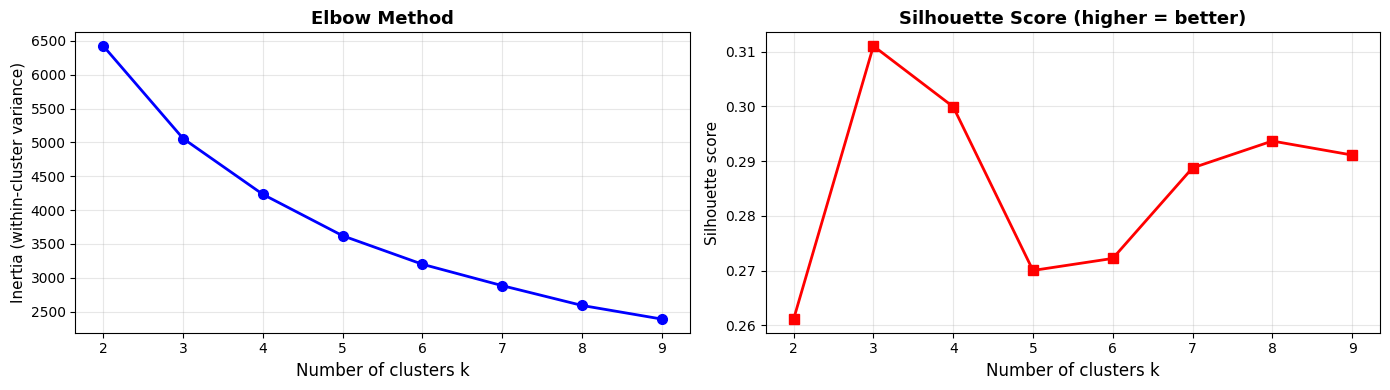

💡 Look for the 'elbow' in inertia and the peak in silhouette score.


In [76]:
# Prepare feature matrix for clustering
cluster_features = ['speed_mean', 'angvel_abs_mean', 'z_mean', 'rearing_frac']

# Drop rows with NaN
seg_clean = all_segs_df[cluster_features].dropna()
print(f"Segments available for clustering: {len(seg_clean)}")

# Normalize
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(seg_clean.values)

# ── Elbow method + Silhouette ─────────────────────────────────────────────
k_range    = range(2, 10)
inertias   = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
ax1.set_xlabel('Number of clusters k', fontsize=12)
ax1.set_ylabel('Inertia (within-cluster variance)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouettes, 'rs-', linewidth=2, markersize=7)
ax2.set_xlabel('Number of clusters k', fontsize=12)
ax2.set_ylabel('Silhouette score', fontsize=11)
ax2.set_title('Silhouette Score (higher = better)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("💡 Look for the 'elbow' in inertia and the peak in silhouette score.")

---

## 🎯 Exercise 4: Choose the Number of Clusters

Based on the elbow and silhouette plots above, choose a value of `k`.

**Think about it biologically**: How many distinct behavioral states do you expect this animal to show in a goal-directed navigation task? Common states in a climbing/navigation task might be:
- Directed locomotion (fast, straight)
- Turning / searching (slow, high angular velocity)
- Rearing / exploration
- Pausing / stationary
- Descending


In [77]:
# =============================================================================
# EXERCISE 4: Choose k and fit K-Means
# =============================================================================
# TODO: Set `best_k` based on the plots above.
# HINT: A good k typically gives silhouette > 0.3 and sits at the elbow.
# HINT: Biologically, 3-6 clusters is a reasonable range for this task.

# YOUR CODE HERE
best_k = 3  # <-- replace with your chosen value

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_clust)

# Add cluster labels back to the dataframe
all_segs_df_clean = all_segs_df.dropna(subset=cluster_features).copy()
all_segs_df_clean['cluster'] = cluster_labels

sil = silhouette_score(X_clust, cluster_labels)
print(f"✓ K-Means with k={best_k}")
print(f"  Silhouette score: {sil:.3f}  (>0.3 is reasonable, >0.5 is good)")
print(f"  Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

✓ K-Means with k=3
  Silhouette score: 0.311  (>0.3 is reasonable, >0.5 is good)
  Cluster sizes:
0     287
1     703
2    1185
Name: count, dtype: int64


<details>
<summary>💡 Solution hints (click to expand)</summary>

```python
# Choose k where:
# 1. The inertia curve has its "elbow" (rate of decrease slows)
# 2. The silhouette score is highest
# For a 4-state navigation task a good starting point is k=4:
best_k = 4
```
</details>


## 4.1 Visualize Cluster Profiles

What are the behavioral characteristics of each cluster?

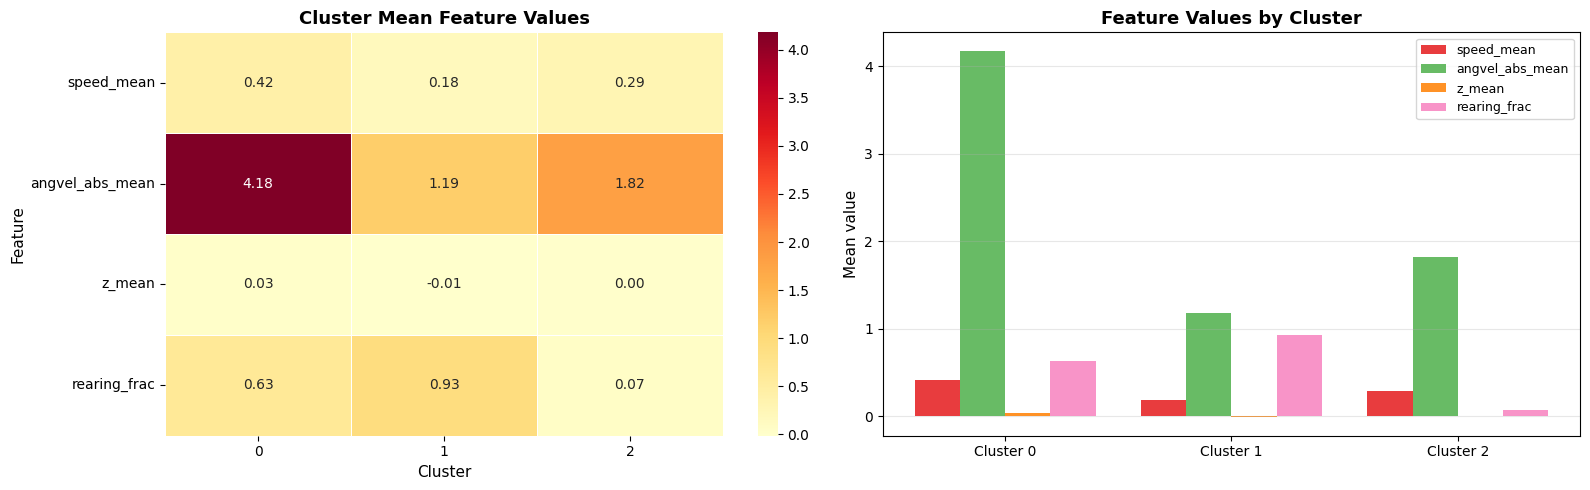


💡 Use the heatmap to assign behavioral labels:
  High speed, low angvel  → likely 'Directed locomotion'
  Low speed, high angvel  → likely 'Turning/searching'
  High rearing_frac       → likely 'Rearing/exploration'
  Low speed + all low     → likely 'Stationary/pause'


In [78]:
# ── Cluster mean profiles ─────────────────────────────────────────────────
cluster_profiles = all_segs_df_clean.groupby('cluster')[cluster_features].mean()

# Normalize for radar/heatmap display
profile_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of raw means
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Cluster Mean Feature Values', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Feature', fontsize=11)

# Bar chart per feature
x = np.arange(best_k)
width = 0.2
palette_clust = plt.cm.Set1(np.linspace(0, 0.8, len(cluster_features)))

for i, (feat, color) in enumerate(zip(cluster_features, palette_clust)):
    axes[1].bar(x + i*width, cluster_profiles[feat], width, label=feat, color=color, alpha=0.85)

axes[1].set_xticks(x + width*(len(cluster_features)-1)/2)
axes[1].set_xticklabels([f'Cluster {c}' for c in range(best_k)])
axes[1].set_ylabel('Mean value', fontsize=11)
axes[1].set_title('Feature Values by Cluster', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 Use the heatmap to assign behavioral labels:")
print("  High speed, low angvel  → likely 'Directed locomotion'")
print("  Low speed, high angvel  → likely 'Turning/searching'")
print("  High rearing_frac       → likely 'Rearing/exploration'")
print("  Low speed + all low     → likely 'Stationary/pause'")

## 4.2 Assign Behavioral Labels

Based on the cluster profiles, give each cluster a human-readable name.

In [79]:
# =============================================================================
# EXERCISE 4 (continued): Assign behavioral labels to clusters
# =============================================================================
# TODO: Based on the heatmap, fill in the label_map dictionary.
#       Keys = cluster numbers (0 to best_k-1), Values = your behavioral label.
#
# Example labels: 'Directed movement', 'Turning/searching', 'Rearing',
#                 'Stationary', 'Descending', 'Slow exploration', etc.

# YOUR CODE HERE
label_map = {
    0: 'State 0',  # <-- replace with your interpretation
    1: 'State 1',
    2: 'State 2',
}
# (add more entries if best_k > 4)

all_segs_df_clean['behavior'] = all_segs_df_clean['cluster'].map(label_map)
print("Behavioral label distribution:")
print(all_segs_df_clean['behavior'].value_counts())

Behavioral label distribution:
behavior
State 2    1185
State 1     703
State 0     287
Name: count, dtype: int64


## 4.3 Visualize Clusters in Feature Space (PCA)

Project the 4-dimensional feature space into 2D using PCA.

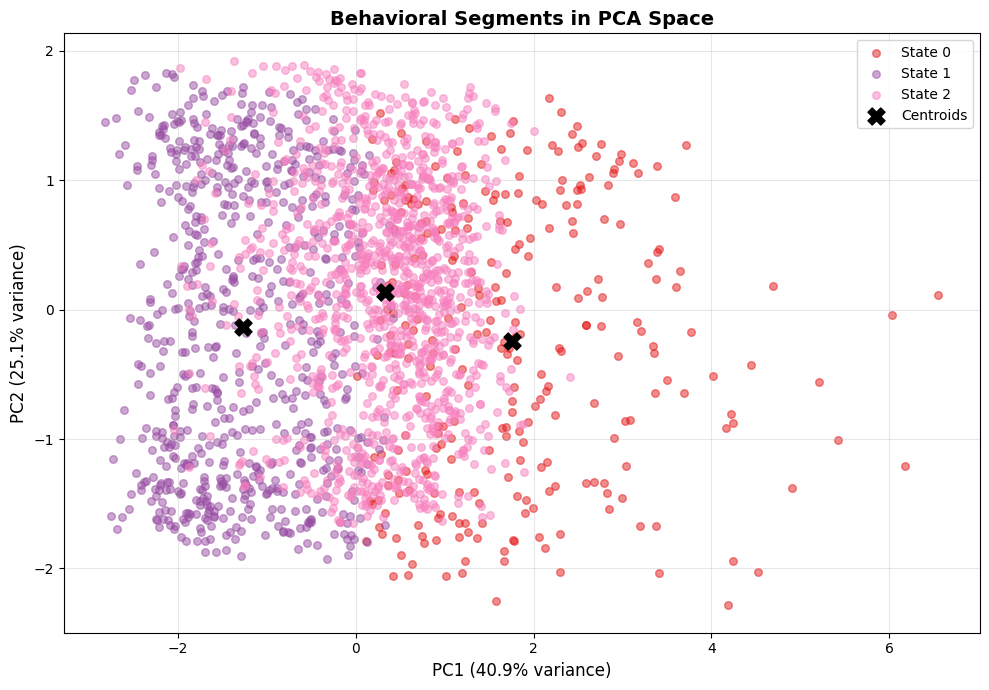


PCA explained variance: PC1=40.9%, PC2=25.1%


In [80]:
# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust)

fig, ax = plt.subplots(figsize=(10, 7))

palette_states = plt.cm.Set1(np.linspace(0, 0.8, best_k))

for c in range(best_k):
    mask = cluster_labels == c
    label = label_map.get(c, f'Cluster {c}')
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=palette_states[c], alpha=0.5, s=30, label=label)

# Mark cluster centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           color='black', s=150, marker='X', zorder=10, label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Behavioral Segments in PCA Space', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

## 4.4 Visualize Behavioral States on a Trial Trajectory

Now let's color the actual animal path by the behavioral state of each segment.

  Outliers removed: 5 frames (0.4%) above 30.0 rad/s


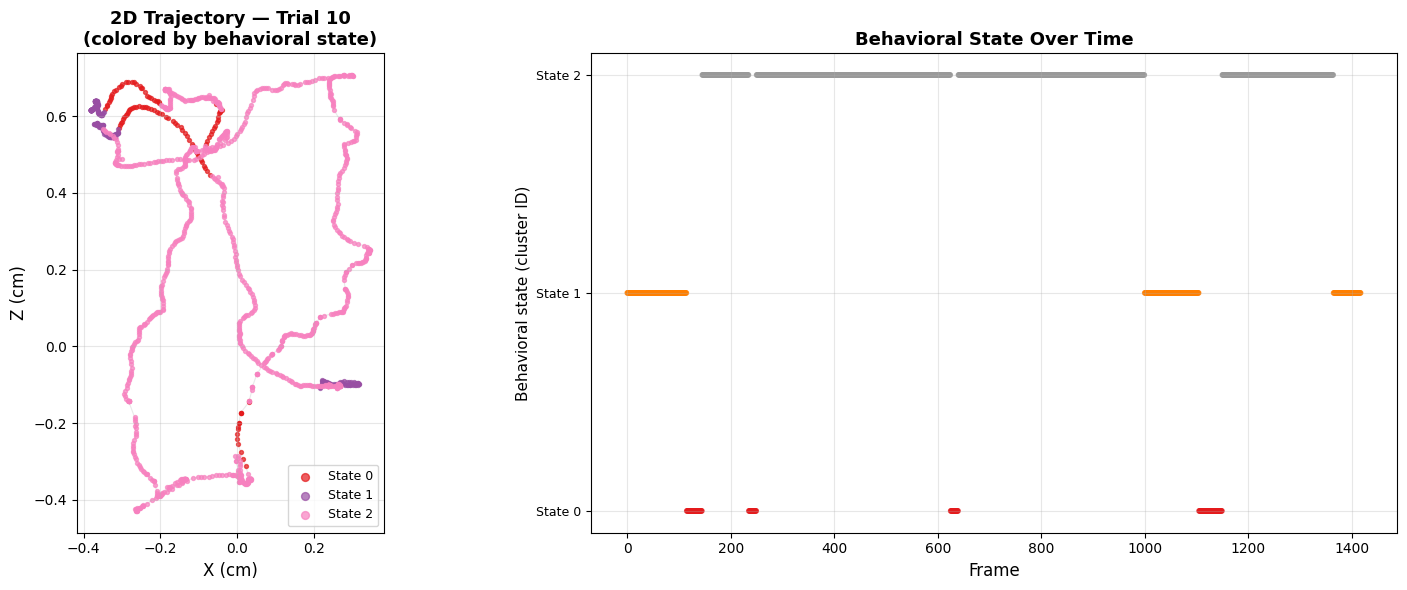

In [81]:
# ── Re-run segmentation on a single trial and map cluster labels ────────
trial_df_clust, bkps_clust, seg_stats_clust = segment_trial(
    df[df['trial_id'] == selected_trial].copy(), model='l1', penalty=pen_multi)

# Normalize and predict cluster for each segment
X_trial = seg_stats_clust[cluster_features].dropna().values
X_trial_norm = scaler_clust.transform(X_trial)
seg_cluster_labels = km_final.predict(X_trial_norm)

# Map cluster labels back to frames
seg_to_cluster = {seg_id: clu for seg_id, clu in enumerate(seg_cluster_labels)}
trial_df_clust['cluster'] = trial_df_clust['segment'].map(seg_to_cluster)
trial_df_clust['behavior'] = trial_df_clust['cluster'].map(label_map)

# ── 2D trajectory colored by behavioral state ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for c in range(best_k):
    mask = trial_df_clust['cluster'] == c
    if mask.any():
        color = palette_states[c]
        label = label_map.get(c, f'Cluster {c}')
        ax1.scatter(trial_df_clust.loc[mask, 'x'],
                    trial_df_clust.loc[mask, 'z'],
                    color=color, s=8, alpha=0.7, label=label)

# Draw trajectory line in gray
ax1.plot(trial_df_clust['x'], trial_df_clust['z'],
         color='lightgray', linewidth=0.8, zorder=0, alpha=0.5)
ax1.set_xlabel('X (cm)', fontsize=12)
ax1.set_ylabel('Z (cm)', fontsize=12)
ax1.set_title(f'2D Trajectory — Trial {selected_trial}\n(colored by behavioral state)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, markerscale=2)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# ── Time-series of behavioral state ────────────────────────────────────
cmap_discrete = plt.cm.Set1
ax2.scatter(trial_df_clust['frame'], trial_df_clust['cluster'],
            c=trial_df_clust['cluster'], cmap='Set1', vmin=0, vmax=best_k-1,
            s=10, alpha=0.7)
ax2.set_xlabel('Frame', fontsize=12)
ax2.set_ylabel('Behavioral state (cluster ID)', fontsize=11)
ax2.set_yticks(range(best_k))
ax2.set_yticklabels([label_map.get(c, f'Cluster {c}') for c in range(best_k)], fontsize=9)
ax2.set_title('Behavioral State Over Time', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.5 Behavioral State Composition: Success vs Failure

Do successful and failed trials differ in the time spent in each behavioral state?

In [ ]:
# Compute cluster proportions per trial
trial_cluster_props = []

for trial_id in trial_ids[:n_trials_to_process]:
    trial_data = df[df['trial_id'] == trial_id].copy()
    try:
        t_out, bkps_t, stats_t = segment_trial(trial_data, model='l1', penalty=pen_multi)
        X_t = stats_t[cluster_features].dropna().values
        if len(X_t) == 0:
            continue
        X_t_norm = scaler_clust.transform(X_t)
        c_labels = km_final.predict(X_t_norm)

        # Weight by n_frames
        frames_per_seg = stats_t['n_frames'].values[:len(c_labels)]
        total_frames = frames_per_seg.sum()
        
        row = {'trial_id': trial_id, 'success': trial_data['success'].iloc[0]}
        for c in range(best_k):
            mask_c = (c_labels == c)
            row[f'frac_cluster_{c}'] = frames_per_seg[mask_c].sum() / total_frames
        trial_cluster_props.append(row)
    except:
        pass

props_df = pd.DataFrame(trial_cluster_props)
frac_cols = [f'frac_cluster_{c}' for c in range(best_k)]

# Plot: success vs failure for each cluster proportion
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(best_k)
width = 0.35

for outcome, color, offset, lbl in [(0, 'tomato', -width/2, 'Failed'), 
                                     (1, 'steelblue', width/2, 'Successful')]:
    sub = props_df[props_df['success'] == outcome][frac_cols]
    means = sub.mean().values
    sems  = sub.sem().values
    bars = ax.bar(x_pos + offset, means, width, color=color, alpha=0.8,
                  label=lbl, yerr=sems, capsize=4)

ax.set_xticks(x_pos)
ax.set_xticklabels([label_map.get(c, f'Cluster {c}') for c in range(best_k)], fontsize=10)
ax.set_ylabel('Fraction of trial time', fontsize=12)
ax.set_title('Time Spent in Each Behavioral State: Success vs Failure', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n✍️ Reflection Questions:")
print("1. Which behavioral states are more common in successful trials?")
print("2. Do failed trials spend more time in 'searching' states?")
print("3. How does this relate to path efficiency?")

---

# Summary & Key Takeaways

## What We Learned Today

### Part 1-2: Change Point Detection
1. **Objective segmentation** removes human bias from behavioral analysis
2. **PELT algorithm** finds optimal change points by minimising cost + penalty
3. **Model choice matters**: `l1` is more robust to noisy tracking data than `l2`
4. **Penalty parameter** controls granularity — use visual inspection and domain knowledge to choose
5. **Multi-feature detection** captures transitions invisible in a single signal

### Part 3-4: Clustering Behavioral States
6. **Segment features** (speed, angular velocity, height, rearing) characterize each behavioral bout
7. **K-Means clustering** groups segments into recurring behavioral states
8. **Elbow + Silhouette** methods guide choice of k
9. **Cluster profiles** enable data-driven behavioral labeling
10. **Success vs failure** differences emerge from behavioral state composition

## Connection to Day 5

- **Day 5**: Segment transitions → **behavioral grammar** (Hidden Markov Models)
- Cluster labels become the **discrete states** in a transition matrix
- Path efficiency metrics → navigation strategy classification

---

## 🔬 Extension Ideas

1. **Automatic penalty selection**: Implement BIC/AIC over a range of penalties
2. **Hierarchical segmentation**: Coarse segments → fine sub-segments
3. **Try other clustering**: Gaussian Mixture Models (GMM) give soft cluster assignments
4. **Temporal features**: Add segment duration, position within trial as clustering features
5. **Cross-trial consistency**: How stable are cluster identities across different trials?

---

## 📚 Further Reading

- **Edelhoff et al. (2016)**: Path segmentation for beginners — [10.1111/2041-210X.12578](https://doi.org/10.1111/2041-210X.12578)
- **Ruptures documentation**: https://centre-borelli.github.io/ruptures-docs/
- **Scikit-learn K-Means**: https://scikit-learn.org/stable/modules/clustering.html#k-means